In [15]:
import numpy as np
from utilities import fortran_restart_to_radstate, setup_infrastructure

from pySHiELD.radiation import RadiationState, RadiationConfig, RTE_RRTMGPDriver
from pySHiELD.physics_state import SurfaceState
from pySHiELD._config import PhysicsConfig
from pySHiELD.stencils.physics import calc_sigma

import matplotlib.pyplot as plt
import datetime
from pathlib import Path

In [20]:
dycore_data = Path("../../test_data/radtest/fv_core.res.tile1.nc")
phys_data = Path("../../test_data/radtest/phy_data.tile1.nc")
tracer_data = Path("../../test_data/radtest/fv_tracer.res.tile1.nc")

In [13]:
nx = 48
ny = 48
nz = 91
npx = nx + 1
npy = ny + 1
npz = nz + 1
levels = np.arange(npz)
layers = np.arange(nz)

date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)

In [6]:
quantity_factory, stencil_factory, grid_data = setup_infrastructure(nx, ny, nz, "eta91.nc")

In [7]:
# Quick fix:
grid_data.lon_agrid.field[:] = grid_data.lon.field[:-1,:-1]
grid_data.lat_agrid.field[:] = grid_data.lat.field[:-1,:-1]

In [16]:
conf = PhysicsConfig
radconf = RadiationConfig(
    deltsw = 3600.0,
    delt_rad = 3600.0,
    date=date,
    fhswr=1.0,
    fhlwr=1.0,
    isolar=10,
    icmphys=4,
    ico2flg=0,
    ioznflg=1,
    ictmflg=-1,
    ialbflg=-1,
    iemsflg=0,
    ldisable_radiation_quasi_sea_ice=False,
    solar_constant_file=Path("global_solarconstant_noaa_an.txt"),
    input_dir=Path("../../test_data/"),
    aerosol_file=Path("../../test_data/"),
    sollat=0.0,
    nstp=6,
    ivflip=1,
    lcnorm=False,
    lcrick=False,
    gfs_cloud_overlap=False,
)

In [17]:
sigma = calc_sigma(grid_data.ak.data, grid_data.bk.data)
gridlon = grid_data.lon_agrid
gridlat = grid_data.lat_agrid

In [18]:
rad = RTE_RRTMGPDriver(config=radconf, gridlon=gridlon, gridlat=gridlat, sigma=sigma, quantity_factory=quantity_factory, stencil_factory=stencil_factory)

2025-08-01 16:42:54|INFO|rank 0|ndsl.logging: - Using new fixed solar constant =1360.8
2025-08-01 16:42:54|INFO|rank 0|ndsl.logging:Using Constant Albedo 0.98
2025-08-01 16:42:54|INFO|rank 0|ndsl.logging:Enable radiation quasi-sea-ice
2025-08-01 16:42:54|INFO|rank 0|ndsl.logging:Using Fixed Surface Emissivity = 1.0 for lw


/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)


In [19]:
state = RadiationState.init_zeros(quantity_factory, np)
sstate = SurfaceState.init_zeros(quantity_factory)

In [21]:
fortran_restart_to_radstate(dycore_datafile=dycore_data, phys_datafile=phys_data, tracer_datafile=tracer_data, ak=grid_data.ak, state=state)

In [23]:
rad.step_radiation(state, sstate, date)

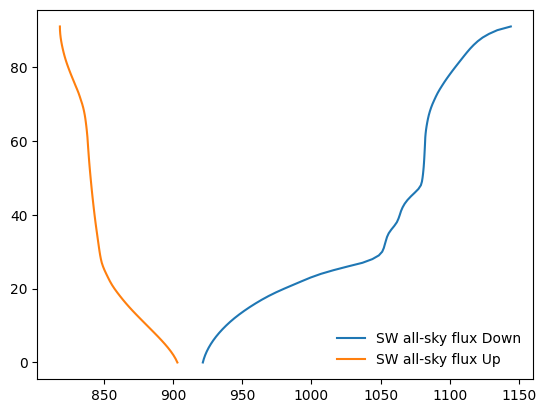

In [24]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.legend(frameon=False)

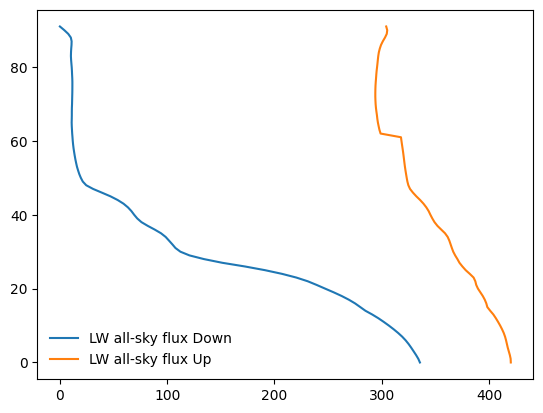

In [25]:
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)

In [28]:
newdate = date + datetime.timedelta(hours=12)
print(newdate)
rad.step_radiation(state, sstate, date)

2020-01-02 00:00:00+00:00


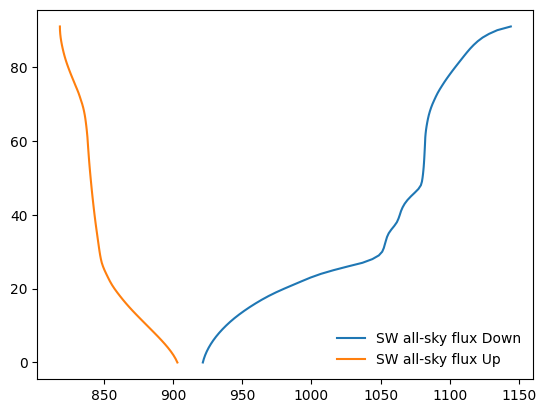

In [29]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.legend(frameon=False)

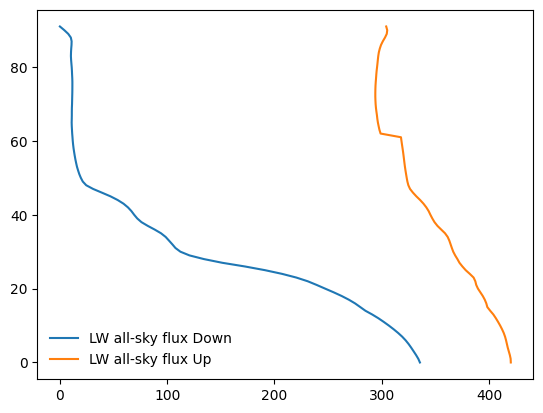

In [30]:
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)